# 🫁 ResNet50 – Chẩn đoán Viêm Phổi (Lung Opacity vs Normal)

### Các kỹ thuật nâng cao được áp dụng:
| Kỹ thuật | Mô tả |
|---|---|
| **Transfer Learning 2 giai đoạn** | Phase 1: freeze backbone → Phase 2: fine-tune toàn bộ |
| **GAP + GMP** | Concat Global Avg Pool & Global Max Pool làm feature richer |
| **Focal Loss + Label Smoothing** | Xử lý class imbalance + tránh overconfident |
| **WeightedRandomSampler** | Oversample class thiểu số khi load data |
| **MixUp + CutMix** | Data augmentation mạnh, mix 2 ảnh theo tỉ lệ β |
| **RandomErasing (Cutout)** | Che ngẫu nhiên một vùng ảnh |
| **Warmup + Cosine Annealing LR** | LR tăng dần → giảm mượt theo cosine |
| **Mixed Precision (AMP)** | FP16 training – nhanh hơn, tiết kiệm VRAM |
| **Gradient Clipping** | Tránh gradient exploding |
| **Early Stopping** | Dừng sớm khi val AUC không cải thiện |
| **Test-Time Augmentation (TTA)** | Inference với 4 transform, average probabilities |

## 📦 1. Cài đặt thư viện

In [96]:
!pip install torch torchvision scikit-learn matplotlib seaborn Pillow pydicom opencv-python-headless -q

## 📚 2. Import thư viện

In [97]:
import os
import copy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image

import pydicom
import cv2

import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.amp import GradScaler
from torch.amp import autocast

import torchvision
from torchvision import models, transforms
from torchvision.transforms import functional as TF

from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, accuracy_score, f1_score
)

print(f'PyTorch version: {torch.__version__}')
print(f'CUDA available : {torch.cuda.is_available()}')
print(f'pydicom version: {pydicom.__version__}')
if torch.cuda.is_available():
    print(f'GPU            : {torch.cuda.get_device_name(0)}')

PyTorch version: 2.9.0+cu126
CUDA available : True
pydicom version: 3.0.1
GPU            : Tesla P100-PCIE-16GB


## ⚙️ 3. Cấu hình (Config)

In [98]:
class Config:
    # ── Đường dẫn dataset ──
    DATA_DIR    = '/kaggle/input/datasets/tomoeee/dataset/dataset_rsna_final_2class/dataset_rsna_final_2class'
    TRAIN_DIR   = os.path.join(DATA_DIR, 'train')
    VAL_DIR     = os.path.join(DATA_DIR, 'val')
    TEST_DIR    = os.path.join(DATA_DIR, 'test')

    CLASSES     = ['normal', 'lung_opacity']   # 0 / 1
    NUM_CLASSES = 2
    IMG_SIZE    = 224

    # ── Training ──
    BATCH_SIZE  = 32
    NUM_WORKERS = 4
    EPOCHS      = 30
    SEED        = 42

    # ── Learning rate ──
    LR_HEAD       = 1e-3   # Phase 1: chỉ train head
    LR_FULL       = 1e-4   # Phase 2: fine-tune toàn bộ
    PHASE1_EPOCHS = 5      # epochs train head trước khi mở backbone
    WEIGHT_DECAY  = 1e-4
    WARMUP_EPOCHS = 3
    GRAD_CLIP     = 1.0

    # ── Regularization ──
    LABEL_SMOOTHING = 0.1
    DROPOUT         = 0.5
    MIXUP_ALPHA     = 0.4   # 0 = tắt mixup
    CUTMIX_ALPHA    = 1.0

    # ── Focal Loss ──
    FOCAL_GAMMA = 2.0

    # ── Mixed precision ──
    USE_AMP = True

    # ── Checkpoints ──
    SAVE_DIR = './checkpoints'
    os.makedirs(SAVE_DIR, exist_ok=True)

    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

cfg = Config()
print(f'[Device] {cfg.DEVICE}')
print(f'[Config] IMG_SIZE={cfg.IMG_SIZE}  BATCH={cfg.BATCH_SIZE}  EPOCHS={cfg.EPOCHS}')

[Device] cuda
[Config] IMG_SIZE=224  BATCH=32  EPOCHS=30


## 🎲 4. Reproducibility – Seed

In [99]:
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f'[Seed] {seed} set ✓')

seed_everything(cfg.SEED)

[Seed] 42 set ✓


## 🖼️ 5. Transforms & Data Augmentation

> **Train**: Augmentation mạnh (flip, rotate, jitter, affine, blur, RandomErasing)  
> **Val/Test**: Chỉ resize + normalize  
> **TTA**: 4 transform khác nhau để average tại inference

In [100]:
# ImageNet mean/std
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

# ── Train: augmentation mạnh ──
train_transform = transforms.Compose([
    transforms.Resize((cfg.IMG_SIZE + 32, cfg.IMG_SIZE + 32)),
    transforms.RandomCrop(cfg.IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(p=0.1),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.85, 1.15)),
    transforms.RandomGrayscale(p=0.05),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.2)),  # Cutout
])

# ── Val/Test: chỉ resize + normalize ──
val_transform = transforms.Compose([
    transforms.Resize((cfg.IMG_SIZE, cfg.IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

# ── TTA: 4 transform nhẹ khác nhau ──
tta_transforms = [
    val_transform,
    transforms.Compose([
        transforms.Resize((cfg.IMG_SIZE, cfg.IMG_SIZE)),
        transforms.RandomHorizontalFlip(p=1.0),
        transforms.ToTensor(), transforms.Normalize(MEAN, STD),
    ]),
    transforms.Compose([
        transforms.Resize((cfg.IMG_SIZE + 20, cfg.IMG_SIZE + 20)),
        transforms.CenterCrop(cfg.IMG_SIZE),
        transforms.ToTensor(), transforms.Normalize(MEAN, STD),
    ]),
    transforms.Compose([
        transforms.Resize((cfg.IMG_SIZE, cfg.IMG_SIZE)),
        transforms.RandomRotation(10),
        transforms.ToTensor(), transforms.Normalize(MEAN, STD),
    ]),
]
print('Transforms ready ✓')

Transforms ready ✓


## 📁 6. Dataset & DataLoader

> **WeightedRandomSampler**: Tự động cân bằng class imbalance bằng cách oversample class thiểu số trong mỗi batch.

In [101]:
# ── Chẩn đoán cấu trúc thư mục dataset trước khi load ──
print('📂 Kiểm tra cấu trúc dataset:')
print(f'  DATA_DIR = {cfg.DATA_DIR}  → exists: {Path(cfg.DATA_DIR).exists()}')
_exts = {'.dcm'}
for _split in ['train', 'val', 'test']:
    _sd = Path(cfg.DATA_DIR) / _split
    print(f'\n  [{_split}] exists={_sd.exists()}')
    if _sd.exists():
        for _cls in cfg.CLASSES:
            _cd = _sd / _cls
            if _cd.exists():
                _n = sum(1 for f in _cd.iterdir() if f.suffix.lower() in _exts)
                print(f'    {_cls}: {_n} ảnh  {"✅" if _n > 0 else "❌ EMPTY!"}')
            else:
                _actual = [d.name for d in _sd.iterdir() if d.is_dir()]
                print(f'    {_cls}: ❌ không tìm thấy  (thư mục thực tế: {_actual})')
print('\nNếu có ❌ → sửa cfg.DATA_DIR hoặc cfg.CLASSES cho khớp tên thư mục thực tế.')

📂 Kiểm tra cấu trúc dataset:
  DATA_DIR = /kaggle/input/datasets/tomoeee/dataset/dataset_rsna_final_2class/dataset_rsna_final_2class  → exists: True

  [train] exists=True
    normal: 14470 ảnh  ✅
    lung_opacity: 4208 ảnh  ✅

  [val] exists=True
    normal: 3049 ảnh  ✅
    lung_opacity: 875 ảnh  ✅

  [test] exists=True
    normal: 3101 ảnh  ✅
    lung_opacity: 902 ảnh  ✅

Nếu có ❌ → sửa cfg.DATA_DIR hoặc cfg.CLASSES cho khớp tên thư mục thực tế.


In [102]:
# ─────────────────────────────────────────────
# Hàm đọc DICOM → PIL Image (RGB)
# ─────────────────────────────────────────────
def load_dicom_as_pil(path: str) -> Image.Image:
    """
    Đọc file .dcm và chuyển sang PIL Image (RGB 8-bit).
    Xử lý:
      - VOI LUT (Window Center/Width) nếu có
      - MONOCHROME1 (invert) vs MONOCHROME2
      - Normalize về [0, 255] uint8
      - Đổi sang RGB để tương thích với ImageNet pretrained
    """
    dcm = pydicom.dcmread(path)
    img = dcm.pixel_array.astype(np.float32)

    # ── Áp dụng VOI LUT (windowing) nếu có ──
    try:
        from pydicom.pixel_data_handlers.util import apply_voi_lut
        img = apply_voi_lut(img, dcm).astype(np.float32)
    except Exception:
        pass  # Không có VOI LUT, dùng raw pixel

    # ── MONOCHROME1: invert (sáng = thấp) ──
    pi = getattr(dcm, 'PhotometricInterpretation', 'MONOCHROME2')
    if 'MONOCHROME1' in str(pi):
        img = img.max() - img

    # ── Normalize về [0, 255] ──
    img_min, img_max = img.min(), img.max()
    if img_max > img_min:
        img = (img - img_min) / (img_max - img_min) * 255.0
    img = img.astype(np.uint8)

    # ── Đổi sang RGB (3 kênh) ──
    if img.ndim == 2:
        img = np.stack([img] * 3, axis=-1)   # grayscale → RGB
    elif img.shape[-1] == 1:
        img = np.concatenate([img] * 3, axis=-1)

    pil_img = Image.fromarray(img)
    return pil_img.convert('RGB')


class PneumoniaDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.transform = transform
        self.samples   = []  # list of (path, label)
        self.class_to_idx = {c: i for i, c in enumerate(cfg.CLASSES)}

        for cls_name in cfg.CLASSES:
            cls_dir = Path(root_dir) / cls_name
            if not cls_dir.exists():
                print(f'  [WARN] Không tìm thấy: {cls_dir}')
                continue
            label = self.class_to_idx[cls_name]
            # Chấp nhận cả .dcm lẫn ảnh thường
            exts  = {'.dcm', '.jpg', '.jpeg', '.png', '.bmp'}
            for fp in cls_dir.iterdir():
                if fp.suffix.lower() in exts:
                    self.samples.append((str(fp), label))

        print(f'  {root_dir}: {len(self.samples)} files')
        counts = self.get_class_counts()
        for i, c in enumerate(cfg.CLASSES):
            print(f'     {c}: {counts[i]}')

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        # Đọc tùy theo định dạng
        if path.lower().endswith('.dcm'):
            img = load_dicom_as_pil(path)
        else:
            img = Image.open(path).convert('RGB')
        if self.transform: img = self.transform(img)
        return img, label

    def get_class_counts(self):
        counts = [0] * cfg.NUM_CLASSES
        for _, lbl in self.samples: counts[lbl] += 1
        return counts


def make_weighted_sampler(dataset):
    """WeightedRandomSampler: xử lý class imbalance"""
    counts = dataset.get_class_counts()
    total  = sum(counts)
    print(f'  Class counts: { {c: counts[i] for i, c in enumerate(cfg.CLASSES)} }')
    # Kiểm tra class rỗng
    for i, (c, cnt) in enumerate(zip(cfg.CLASSES, counts)):
        if cnt == 0:
            raise ValueError(
                f"[ERROR] Class '{c}' có 0 ảnh trong train set!\n"
                f"  → Kiểm tra thư mục: {cfg.TRAIN_DIR}/{c}\n"
                f"  → Đảm bảo tên thư mục khớp với cfg.CLASSES = {cfg.CLASSES}"
            )
    weights = [total / (cfg.NUM_CLASSES * c) for c in counts]
    sample_weights = [weights[lbl] for _, lbl in dataset.samples]
    return WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)


def build_dataloaders():
    print('[Data] Loading dataset...')
    train_ds = PneumoniaDataset(cfg.TRAIN_DIR, transform=train_transform)
    val_ds   = PneumoniaDataset(cfg.VAL_DIR,   transform=val_transform)
    test_ds  = PneumoniaDataset(cfg.TEST_DIR,  transform=val_transform)

    sampler = make_weighted_sampler(train_ds)

    train_loader = DataLoader(train_ds, batch_size=cfg.BATCH_SIZE,
                              sampler=sampler, num_workers=cfg.NUM_WORKERS, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=cfg.BATCH_SIZE,
                              shuffle=False, num_workers=cfg.NUM_WORKERS, pin_memory=True)
    test_loader  = DataLoader(test_ds,  batch_size=cfg.BATCH_SIZE,
                              shuffle=False, num_workers=cfg.NUM_WORKERS, pin_memory=True)
    return train_loader, val_loader, test_loader, train_ds, test_ds


train_loader, val_loader, test_loader, train_ds, test_ds = build_dataloaders()

[Data] Loading dataset...
  /kaggle/input/datasets/tomoeee/dataset/dataset_rsna_final_2class/dataset_rsna_final_2class/train: 18678 files
     normal: 14470
     lung_opacity: 4208
  /kaggle/input/datasets/tomoeee/dataset/dataset_rsna_final_2class/dataset_rsna_final_2class/val: 3924 files
     normal: 3049
     lung_opacity: 875
  /kaggle/input/datasets/tomoeee/dataset/dataset_rsna_final_2class/dataset_rsna_final_2class/test: 4003 files
     normal: 3101
     lung_opacity: 902
  Class counts: {'normal': 14470, 'lung_opacity': 4208}


### Xem mẫu ảnh từ dataset

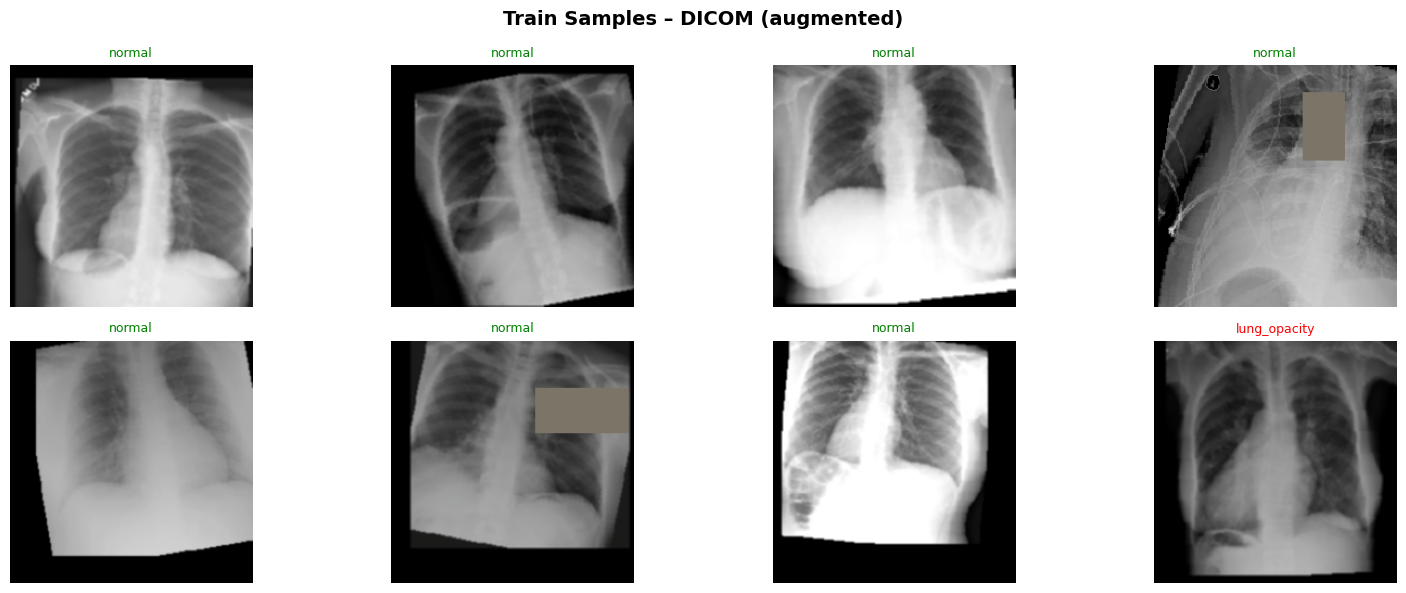

File      : c3b05294-29be-46e4-8a51-96fd211e4ca5.dcm
Label     : normal
Shape     : (1024, 1024)
Dtype     : uint8
PatientID                     : c3b05294-29be-46e4-8a51-96fd211e4ca5
StudyDescription              : N/A
Modality                      : CR
PhotometricInterpretation     : MONOCHROME2
WindowCenter                  : N/A
WindowWidth                   : N/A


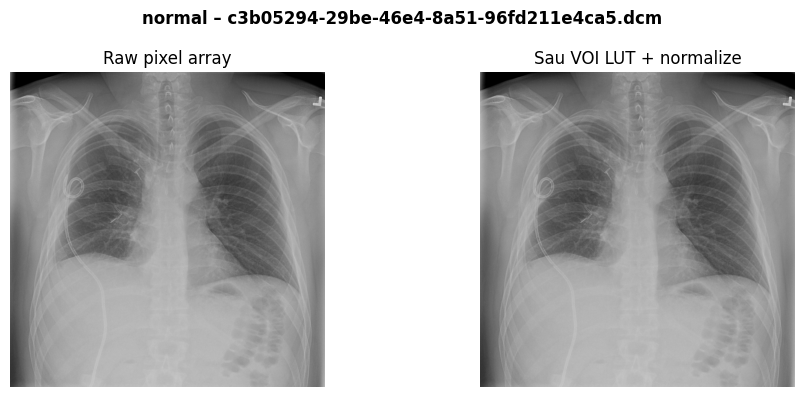

In [103]:
def show_samples(dataset, n=8, title='Samples'):
    """Hiển thị mẫu ảnh từ dataset (hỗ trợ cả DICOM và ảnh thường)"""
    fig, axes = plt.subplots(2, n//2, figsize=(16, 6))
    fig.suptitle(title, fontsize=14, fontweight='bold')
    indices = random.sample(range(len(dataset)), min(n, len(dataset)))
    unnorm  = transforms.Normalize(
        mean=[-m/s for m,s in zip(MEAN,STD)],
        std=[1/s for s in STD]
    )
    for ax, idx in zip(axes.flatten(), indices):
        img_t, lbl = dataset[idx]
        img = unnorm(img_t).permute(1,2,0).numpy().clip(0,1)
        ax.imshow(img, cmap='gray' if img.std() < 0.05 else None)
        ax.set_title(cfg.CLASSES[lbl], color='red' if lbl==1 else 'green', fontsize=9)
        ax.axis('off')
    plt.tight_layout()
    plt.show()


def show_dicom_info(dataset, idx=0):
    """In thông tin DICOM metadata của 1 file"""
    path, label = dataset.samples[idx]
    if not path.lower().endswith('.dcm'):
        print('File không phải DICOM.')
        return
    dcm = pydicom.dcmread(path)
    print(f'File      : {Path(path).name}')
    print(f'Label     : {cfg.CLASSES[label]}')
    print(f'Shape     : {dcm.pixel_array.shape}')
    print(f'Dtype     : {dcm.pixel_array.dtype}')
    for tag in ['PatientID','StudyDescription','Modality',
                'PhotometricInterpretation','WindowCenter','WindowWidth']:
        val = getattr(dcm, tag, 'N/A')
        print(f'{tag:<30}: {val}')
    # Visualize raw vs windowed
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].imshow(dcm.pixel_array, cmap='gray')
    axes[0].set_title('Raw pixel array'); axes[0].axis('off')
    pil_img = load_dicom_as_pil(path)
    axes[1].imshow(pil_img, cmap='gray')
    axes[1].set_title('Sau VOI LUT + normalize'); axes[1].axis('off')
    plt.suptitle(f'{cfg.CLASSES[label]} – {Path(path).name}', fontweight='bold')
    plt.tight_layout(); plt.show()


show_samples(train_ds, n=8, title='Train Samples – DICOM (augmented)')
show_dicom_info(train_ds, idx=0)  # Xem metadata file đầu tiên

## 🧠 7. Model – ResNet50 + Custom Head

> **Kiến trúc**: ResNet50 backbone (ImageNet pretrained) + GAP/GMP concat + FC head  
> **GAP + GMP**: Kết hợp Global Average và Global Max Pooling → feature vector phong phú hơn (4096 chiều thay vì 2048)

In [104]:
class ResNet50Classifier(nn.Module):
    def __init__(self, num_classes=2, dropout=0.5, pretrained=True):
        super().__init__()
        weights  = models.ResNet50_Weights.IMAGENET1K_V2 if pretrained else None
        backbone = models.resnet50(weights=weights)

        # Backbone: tất cả trừ avgpool & fc
        self.features = nn.Sequential(*list(backbone.children())[:-2])

        # GAP + GMP – concat để có feature vector 2048*2 = 4096
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.gmp = nn.AdaptiveMaxPool2d(1)

        in_feat = backbone.fc.in_features  # 2048
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(in_feat * 2, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout / 2),
            nn.Linear(512, num_classes)
        )

    def freeze_backbone(self):
        for p in self.features.parameters(): p.requires_grad = False
        print('[Model] Backbone FROZEN ✓')

    def unfreeze_all(self):
        for p in self.parameters(): p.requires_grad = True
        print('[Model] All layers UNFROZEN ✓')

    def forward(self, x):
        feat = self.features(x)
        gap  = self.gap(feat).flatten(1)
        gmp  = self.gmp(feat).flatten(1)
        return self.head(torch.cat([gap, gmp], dim=1))


# Khởi tạo và in tổng quan
model = ResNet50Classifier(num_classes=cfg.NUM_CLASSES, dropout=cfg.DROPOUT).to(cfg.DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total params    : {total_params:,}')
print(f'Trainable params: {trainable_params:,}')

Total params    : 25,607,746
Trainable params: 25,607,746


## 🎯 8. Focal Loss + Label Smoothing

> **Focal Loss**: Giảm trọng số mẫu dễ, tập trung học mẫu khó → hiệu quả với class imbalance  
> **Label Smoothing**: Làm mềm nhãn từ hard 0/1 → smooth → tránh overconfident

In [105]:
class FocalLoss(nn.Module):
    """Focal Loss + Label Smoothing"""
    def __init__(self, gamma=2.0, smoothing=0.1, weight=None):
        super().__init__()
        self.gamma     = gamma
        self.smoothing = smoothing
        self.weight    = weight

    def forward(self, logits, targets):
        num_classes = logits.size(1)
        with torch.no_grad():
            smooth_labels = torch.zeros_like(logits)
            smooth_labels.fill_(self.smoothing / (num_classes - 1))
            smooth_labels.scatter_(1, targets.unsqueeze(1), 1.0 - self.smoothing)

        log_probs = F.log_softmax(logits, dim=1)
        probs     = log_probs.exp()
        pt        = (probs * smooth_labels).sum(dim=1)
        focal_w   = (1 - pt) ** self.gamma
        loss      = -(smooth_labels * log_probs).sum(dim=1)
        return (focal_w * loss).mean()


# Class weights từ phân phối train set (an toàn với class rỗng)
counts    = train_ds.get_class_counts()
total_cnt = sum(counts)
cls_weights = torch.tensor(
    [total_cnt / (2 * c) if c > 0 else 1.0 for c in counts],
    dtype=torch.float32
).to(cfg.DEVICE)
print(f'Class counts : {dict(zip(cfg.CLASSES, counts))}')
print(f'Class weights: {dict(zip(cfg.CLASSES, cls_weights.tolist()))}')

criterion = FocalLoss(gamma=cfg.FOCAL_GAMMA, smoothing=cfg.LABEL_SMOOTHING,
                      weight=cls_weights)
print('Focal Loss ready ✓')

Class counts : {'normal': 14470, 'lung_opacity': 4208}
Class weights: {'normal': 0.6454042792320251, 'lung_opacity': 2.219344139099121}
Focal Loss ready ✓


## 🔀 9. MixUp & CutMix

> Mỗi iteration ngẫu nhiên chọn 1 trong 3 chế độ: **CutMix** / **MixUp** / **Không augment**

In [106]:
def mixup_data(x, y, alpha=0.4):
    if alpha <= 0: return x, y, y, 1.0
    lam     = np.random.beta(alpha, alpha)
    idx     = torch.randperm(x.size(0), device=x.device)
    mixed_x = lam * x + (1 - lam) * x[idx]
    return mixed_x, y, y[idx], lam


def cutmix_data(x, y, alpha=1.0):
    if alpha <= 0: return x, y, y, 1.0
    lam     = np.random.beta(alpha, alpha)
    B, C, H, W = x.shape
    cut_rat = np.sqrt(1 - lam)
    cut_h, cut_w = int(H * cut_rat), int(W * cut_rat)
    cx, cy = np.random.randint(W), np.random.randint(H)
    x1 = np.clip(cx - cut_w // 2, 0, W)
    x2 = np.clip(cx + cut_w // 2, 0, W)
    y1 = np.clip(cy - cut_h // 2, 0, H)
    y2 = np.clip(cy + cut_h // 2, 0, H)
    idx     = torch.randperm(B, device=x.device)
    mixed_x = x.clone()
    mixed_x[:, :, y1:y2, x1:x2] = x[idx, :, y1:y2, x1:x2]
    lam = 1 - (x2 - x1) * (y2 - y1) / (W * H)
    return mixed_x, y, y[idx], lam


def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

print('MixUp / CutMix functions ready ✓')

MixUp / CutMix functions ready ✓


## 📈 10. LR Scheduler: Warmup + Cosine Annealing

> **Warmup**: LR tăng tuyến tính trong `warmup_epochs` đầu → model ổn định  
> **Cosine Annealing**: LR giảm mượt theo hàm cosine → tránh oscillation cuối training

/usr/local/lib/python3.12/dist-packages/torch/optim/lr_scheduler.py:192: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(


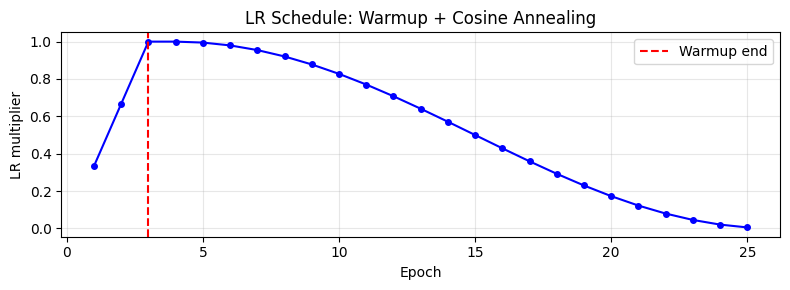

In [107]:
def get_scheduler(optimizer, epochs, warmup_epochs):
    def lr_lambda(epoch):
        if epoch < warmup_epochs:
            return (epoch + 1) / warmup_epochs
        progress = (epoch - warmup_epochs) / max(1, epochs - warmup_epochs)
        return 0.5 * (1.0 + np.cos(np.pi * progress))
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)


# Visualize LR schedule
dummy_opt = torch.optim.Adam([torch.zeros(1, requires_grad=True)], lr=1.0)
sched_vis = get_scheduler(dummy_opt, epochs=25, warmup_epochs=3)
lrs = []
for _ in range(25):
    lrs.append(dummy_opt.param_groups[0]['lr'])
    sched_vis.step()

plt.figure(figsize=(8, 3))
plt.plot(range(1, 26), lrs, 'b-o', markersize=4)
plt.axvline(x=3, color='r', linestyle='--', label='Warmup end')
plt.title('LR Schedule: Warmup + Cosine Annealing')
plt.xlabel('Epoch'); plt.ylabel('LR multiplier'); plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## 🔄 11. Train & Evaluate Functions

> **AMP (autocast)**: Tự động dùng FP16 cho forward/backward → tăng tốc 2-3x trên GPU  
> **Gradient Clipping**: Clip gradient norm ≤ 1.0 → tránh weight update quá lớn

In [108]:
def train_one_epoch(model, loader, optimizer, criterion, scaler, epoch):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for imgs, labels in loader:
        imgs, labels = imgs.to(cfg.DEVICE), labels.to(cfg.DEVICE)

        # Random: CutMix / MixUp / Normal
        r = random.random()
        if cfg.CUTMIX_ALPHA > 0 and r < 0.33:
            imgs, lbl_a, lbl_b, lam = cutmix_data(imgs, labels, cfg.CUTMIX_ALPHA)
            mixed = True
        elif cfg.MIXUP_ALPHA > 0 and r < 0.66:
            imgs, lbl_a, lbl_b, lam = mixup_data(imgs, labels, cfg.MIXUP_ALPHA)
            mixed = True
        else:
            lbl_a, lbl_b, lam, mixed = labels, labels, 1.0, False

        optimizer.zero_grad()
        with autocast('cuda', enabled=cfg.USE_AMP):  # Mixed Precision
            logits = model(imgs)
            loss   = mixup_criterion(criterion, logits, lbl_a, lbl_b, lam) if mixed \
                     else criterion(logits, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.GRAD_CLIP)  # Grad Clip
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item() * imgs.size(0)
        preds   = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total   += labels.size(0)

    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_probs, all_labels = [], [], []

    for imgs, labels in loader:
        imgs, labels = imgs.to(cfg.DEVICE), labels.to(cfg.DEVICE)
        with autocast('cuda', enabled=cfg.USE_AMP):
            logits = model(imgs)
            loss   = criterion(logits, labels)

        total_loss += loss.item() * imgs.size(0)
        probs   = F.softmax(logits, dim=1)
        preds   = probs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total   += labels.size(0)

        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs[:, 1].cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    auc = roc_auc_score(all_labels, all_probs)
    f1  = f1_score(all_labels, all_preds)
    return total_loss / total, correct / total, auc, f1, all_preds, all_probs, all_labels


@torch.no_grad()
def evaluate_tta(model, dataset):
    """Test-Time Augmentation: average probs qua 4 transform"""
    model.eval()
    all_probs, all_labels = [], []

    for i in range(len(dataset)):
        path, label = dataset.samples[i]
        # ✅ Hỗ trợ file .dcm (DICOM) lẫn ảnh thông thường
        if path.lower().endswith('.dcm'):
            img_pil = load_dicom_as_pil(path)
        else:
            img_pil = Image.open(path).convert('RGB')
        probs_list = []
        for tfm in tta_transforms:
            img_t = tfm(img_pil).unsqueeze(0).to(cfg.DEVICE)
            with autocast('cuda', enabled=cfg.USE_AMP):
                p = F.softmax(model(img_t), dim=1)[0, 1].item()
            probs_list.append(p)
        all_probs.append(np.mean(probs_list))
        all_labels.append(label)

    all_preds = [1 if p >= 0.5 else 0 for p in all_probs]
    return (accuracy_score(all_labels, all_preds),
            roc_auc_score(all_labels, all_probs),
            f1_score(all_labels, all_preds),
            all_preds, all_probs, all_labels)

print('Train/Eval functions ready ✓')

Train/Eval functions ready ✓


## ⏹️ 12. Early Stopping

In [109]:
class EarlyStopping:
    def __init__(self, patience=7, mode='max', delta=1e-4):
        self.patience   = patience
        self.mode       = mode
        self.delta      = delta
        self.counter    = 0
        self.best_score = None
        self.stop       = False

    def __call__(self, score, model, path):
        improved = (self.best_score is None) or \
                   (self.mode == 'max' and score > self.best_score + self.delta) or \
                   (self.mode == 'min' and score < self.best_score - self.delta)
        if improved:
            self.best_score = score
            self.counter    = 0
            torch.save(model.state_dict(), path)
            print(f'  ✅ Saved best model (AUC={score:.4f})')
        else:
            self.counter += 1
            print(f'  ⏳ EarlyStopping: {self.counter}/{self.patience}')
            if self.counter >= self.patience:
                self.stop = True

print('EarlyStopping ready ✓')

EarlyStopping ready ✓


## 🚀 13. Training – Phase 1: Freeze Backbone

> Chỉ train **custom head**, backbone được giữ nguyên.  
> Mục đích: khởi tạo head với weights hợp lý trước khi fine-tune toàn bộ.

In [110]:
best_ckpt = os.path.join(cfg.SAVE_DIR, 'best_resnet50.pth')
es        = EarlyStopping(patience=7, mode='max')
device    = 'cuda' if torch.cuda.is_available() else 'cpu'
scaler    = GradScaler(device, enabled=(cfg.USE_AMP and torch.cuda.is_available()))

history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [],
           'val_auc': [], 'val_f1': [], 'lr': []}

# ── Phase 1 ──
print(f"{'='*60}")
print(f'Phase 1: Freeze backbone – train HEAD only ({cfg.PHASE1_EPOCHS} epochs)')
print(f"{'='*60}")

model.freeze_backbone()
optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=cfg.LR_HEAD, weight_decay=cfg.WEIGHT_DECAY
)
scheduler = get_scheduler(optimizer, cfg.PHASE1_EPOCHS, 1)

for epoch in range(1, cfg.PHASE1_EPOCHS + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, scaler, epoch)
    vl_loss, vl_acc, vl_auc, vl_f1, _, _, _ = evaluate(model, val_loader, criterion)
    scheduler.step()
    lr = optimizer.param_groups[0]['lr']
    print(f'  Ep{epoch:02d} | Loss {tr_loss:.4f}/{vl_loss:.4f} | '
          f'Acc {tr_acc:.3f}/{vl_acc:.3f} | AUC {vl_auc:.4f} | LR {lr:.6f}')
    for k, v in zip(['train_loss','val_loss','train_acc','val_acc','val_auc','val_f1','lr'],
                    [tr_loss, vl_loss, tr_acc, vl_acc, vl_auc, vl_f1, lr]):
        history[k].append(v)
    es(vl_auc, model, best_ckpt)

Phase 1: Freeze backbone – train HEAD only (5 epochs)
[Model] Backbone FROZEN ✓
  Ep01 | Loss 0.1750/0.1658 | Acc 0.616/0.622 | AUC 0.7679 | LR 0.001000
  ✅ Saved best model (AUC=0.7679)
  Ep02 | Loss 0.1610/0.1395 | Acc 0.643/0.744 | AUC 0.7755 | LR 0.000854
  ✅ Saved best model (AUC=0.7755)
  Ep03 | Loss 0.1590/0.1555 | Acc 0.646/0.684 | AUC 0.7799 | LR 0.000500
  ✅ Saved best model (AUC=0.7799)
  Ep04 | Loss 0.1561/0.1464 | Acc 0.651/0.714 | AUC 0.7937 | LR 0.000146
  ✅ Saved best model (AUC=0.7937)
  Ep05 | Loss 0.1537/0.1557 | Acc 0.668/0.678 | AUC 0.7986 | LR 0.000000
  ✅ Saved best model (AUC=0.7986)


## 🔥 14. Training – Phase 2: Fine-tune Toàn Bộ

> Unfreeze backbone, dùng **learning rate phân tầng**: backbone (lr nhỏ) vs head (lr lớn hơn 5x)

In [111]:
print(f"{'='*60}")
print(f'Phase 2: Fine-tune ALL layers ({cfg.EPOCHS - cfg.PHASE1_EPOCHS} epochs)')
print(f"{'='*60}")

model.unfreeze_all()
optimizer = optim.AdamW(
    [
        {'params': model.features.parameters(), 'lr': cfg.LR_FULL},
        {'params': model.head.parameters(),     'lr': cfg.LR_FULL * 5},
    ],
    weight_decay=cfg.WEIGHT_DECAY
)
remaining = cfg.EPOCHS - cfg.PHASE1_EPOCHS
scheduler = get_scheduler(optimizer, remaining, cfg.WARMUP_EPOCHS)

for epoch in range(1, remaining + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, scaler, epoch)
    vl_loss, vl_acc, vl_auc, vl_f1, _, _, _ = evaluate(model, val_loader, criterion)
    scheduler.step()
    lr = optimizer.param_groups[0]['lr']
    print(f'  Ep{epoch:02d} | Loss {tr_loss:.4f}/{vl_loss:.4f} | '
          f'Acc {tr_acc:.3f}/{vl_acc:.3f} | AUC {vl_auc:.4f} | LR {lr:.6f}')
    for k, v in zip(['train_loss','val_loss','train_acc','val_acc','val_auc','val_f1','lr'],
                    [tr_loss, vl_loss, tr_acc, vl_acc, vl_auc, vl_f1, lr]):
        history[k].append(v)
    es(vl_auc, model, best_ckpt)
    if es.stop:
        print('  🛑 Early Stopping triggered!')
        break

print(f'\n[Done] Best AUC: {es.best_score:.4f}')

Phase 2: Fine-tune ALL layers (25 epochs)
[Model] All layers UNFROZEN ✓
  Ep01 | Loss 0.1483/0.1267 | Acc 0.686/0.756 | AUC 0.8464 | LR 0.000067
  ✅ Saved best model (AUC=0.8464)
  Ep02 | Loss 0.1448/0.1125 | Acc 0.697/0.802 | AUC 0.8681 | LR 0.000100
  ✅ Saved best model (AUC=0.8681)
  Ep03 | Loss 0.1435/0.1253 | Acc 0.705/0.770 | AUC 0.8693 | LR 0.000100
  ✅ Saved best model (AUC=0.8693)
  Ep04 | Loss 0.1403/0.1240 | Acc 0.710/0.777 | AUC 0.8714 | LR 0.000099
  ✅ Saved best model (AUC=0.8714)
  Ep05 | Loss 0.1382/0.1211 | Acc 0.715/0.801 | AUC 0.8839 | LR 0.000098
  ✅ Saved best model (AUC=0.8839)
  Ep06 | Loss 0.1378/0.1177 | Acc 0.723/0.762 | AUC 0.8792 | LR 0.000095
  ⏳ EarlyStopping: 1/7
  Ep07 | Loss 0.1381/0.1218 | Acc 0.707/0.771 | AUC 0.8839 | LR 0.000092
  ⏳ EarlyStopping: 2/7
  Ep08 | Loss 0.1361/0.1045 | Acc 0.715/0.811 | AUC 0.8867 | LR 0.000088
  ✅ Saved best model (AUC=0.8867)
  Ep09 | Loss 0.1347/0.1226 | Acc 0.722/0.778 | AUC 0.8887 | LR 0.000083
  ✅ Saved best model 

## 📊 15. Đánh giá trên Test Set

In [112]:
# Load best checkpoint
model.load_state_dict(torch.load(best_ckpt, map_location=cfg.DEVICE))
print('Loaded best model ✓')

# Standard evaluation
_, test_acc, test_auc, test_f1, preds, probs, labels = evaluate(model, test_loader, criterion)
print(f'\n[Standard Eval]  Acc={test_acc:.4f}  AUC={test_auc:.4f}  F1={test_f1:.4f}')
print('\n' + classification_report(labels, preds, target_names=cfg.CLASSES))

# TTA evaluation
print('\n[TTA Eval] đang tính...')
tta_acc, tta_auc, tta_f1, tta_preds, tta_probs, tta_labels = evaluate_tta(model, test_ds)
print(f'[TTA Eval]       Acc={tta_acc:.4f}  AUC={tta_auc:.4f}  F1={tta_f1:.4f}')
print(f'\n[Improvement] AUC: {test_auc:.4f} → {tta_auc:.4f} (+{tta_auc-test_auc:.4f})')

Loaded best model ✓

[Standard Eval]  Acc=0.7854  AUC=0.8860  F1=0.6386

              precision    recall  f1-score   support

      normal       0.94      0.77      0.85      3101
lung_opacity       0.51      0.84      0.64       902

    accuracy                           0.79      4003
   macro avg       0.73      0.81      0.74      4003
weighted avg       0.85      0.79      0.80      4003


[TTA Eval] đang tính...
[TTA Eval]       Acc=0.7872  AUC=0.8898  F1=0.6390

[Improvement] AUC: 0.8860 → 0.8898 (+0.0038)


## 📉 16. Visualization – Loss / Accuracy / AUC / Confusion Matrix / ROC

Plot saved: ./checkpoints/results.png


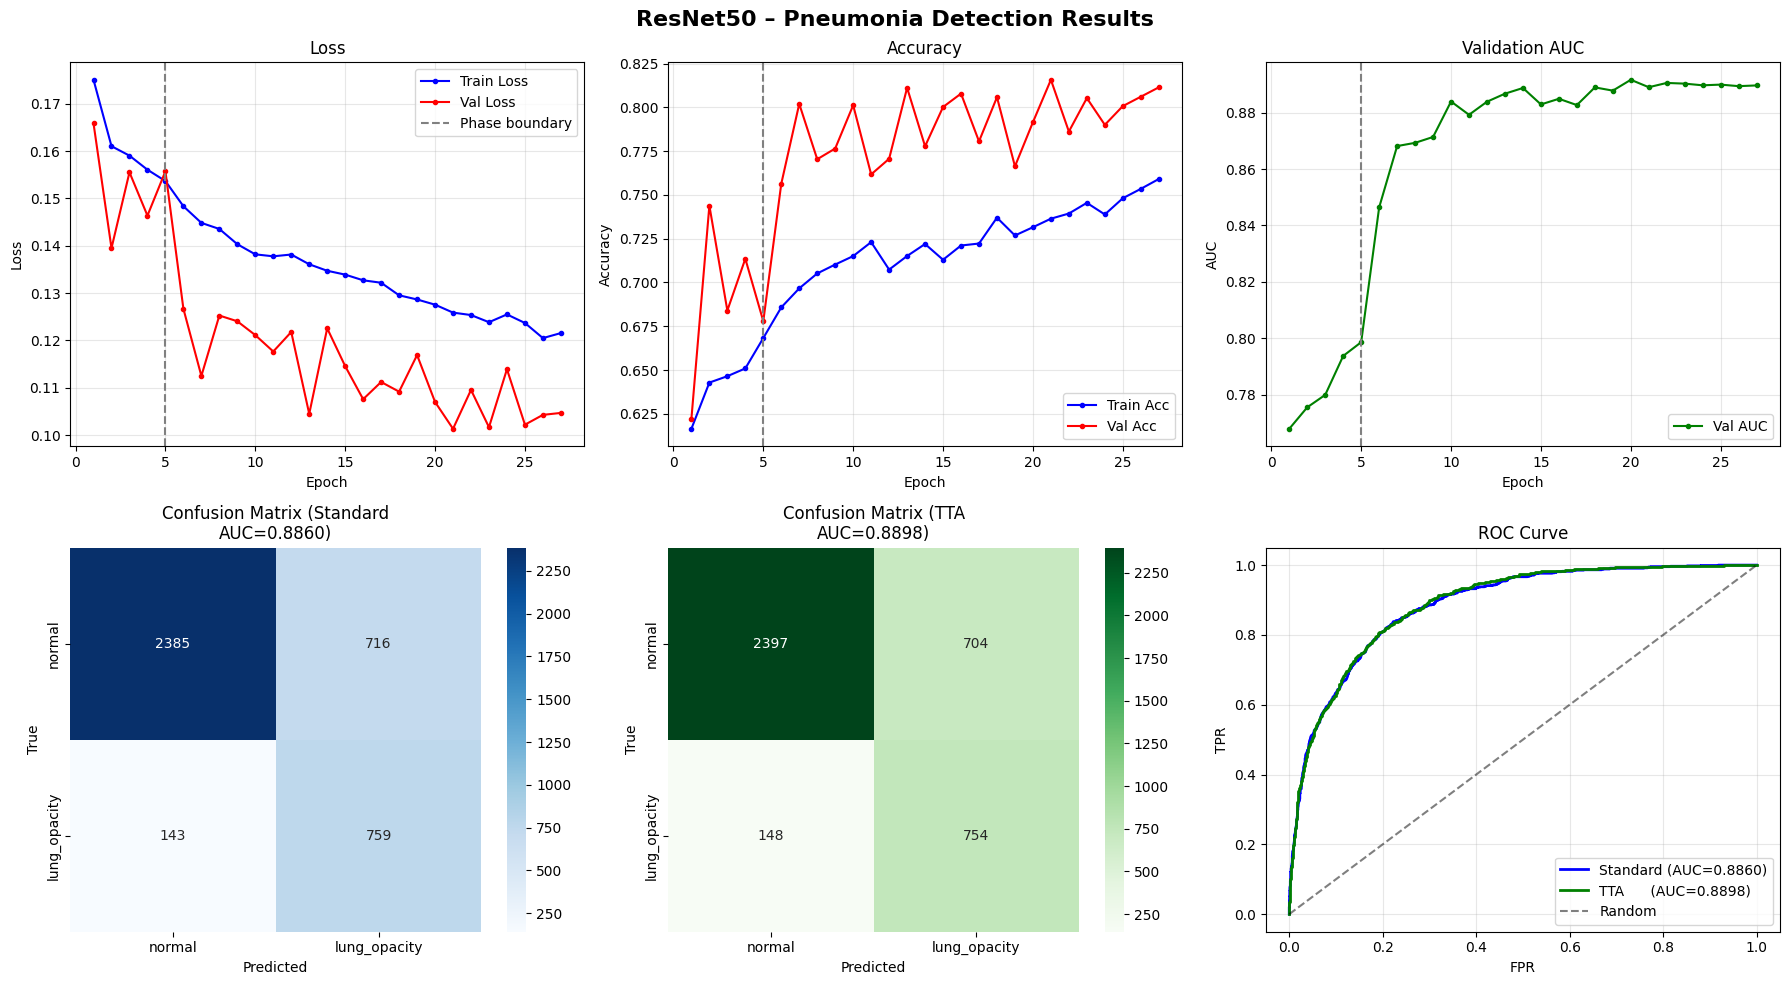

In [113]:
epochs_range = range(1, len(history['train_loss']) + 1)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('ResNet50 – Pneumonia Detection Results', fontsize=16, fontweight='bold')

# Loss
ax = axes[0, 0]
ax.plot(epochs_range, history['train_loss'], 'b-o', label='Train Loss', markersize=3)
ax.plot(epochs_range, history['val_loss'],   'r-o', label='Val Loss',   markersize=3)
ax.axvline(x=cfg.PHASE1_EPOCHS, color='gray', linestyle='--', label='Phase boundary')
ax.set(title='Loss', xlabel='Epoch', ylabel='Loss'); ax.legend(); ax.grid(True, alpha=0.3)

# Accuracy
ax = axes[0, 1]
ax.plot(epochs_range, history['train_acc'], 'b-o', label='Train Acc', markersize=3)
ax.plot(epochs_range, history['val_acc'],   'r-o', label='Val Acc',   markersize=3)
ax.axvline(x=cfg.PHASE1_EPOCHS, color='gray', linestyle='--')
ax.set(title='Accuracy', xlabel='Epoch', ylabel='Accuracy'); ax.legend(); ax.grid(True, alpha=0.3)

# AUC
ax = axes[0, 2]
ax.plot(epochs_range, history['val_auc'], 'g-o', label='Val AUC', markersize=3)
ax.axvline(x=cfg.PHASE1_EPOCHS, color='gray', linestyle='--')
ax.set(title='Validation AUC', xlabel='Epoch', ylabel='AUC'); ax.legend(); ax.grid(True, alpha=0.3)

# Confusion Matrix – Standard
ax = axes[1, 0]
cm = confusion_matrix(labels, preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=cfg.CLASSES, yticklabels=cfg.CLASSES)
ax.set(title=f'Confusion Matrix (Standard\nAUC={test_auc:.4f})', xlabel='Predicted', ylabel='True')

# Confusion Matrix – TTA
ax = axes[1, 1]
cm_tta = confusion_matrix(tta_labels, tta_preds)
sns.heatmap(cm_tta, annot=True, fmt='d', cmap='Greens', ax=ax,
            xticklabels=cfg.CLASSES, yticklabels=cfg.CLASSES)
ax.set(title=f'Confusion Matrix (TTA\nAUC={tta_auc:.4f})', xlabel='Predicted', ylabel='True')

# ROC Curve
ax = axes[1, 2]
fpr,  tpr,  _ = roc_curve(labels,     probs)
fpr2, tpr2, _ = roc_curve(tta_labels, tta_probs)
ax.plot(fpr,  tpr,  'b-', linewidth=2, label=f'Standard (AUC={test_auc:.4f})')
ax.plot(fpr2, tpr2, 'g-', linewidth=2, label=f'TTA      (AUC={tta_auc:.4f})')
ax.plot([0,1],[0,1],'k--', alpha=0.5, label='Random')
ax.set(title='ROC Curve', xlabel='FPR', ylabel='TPR'); ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
out_path = os.path.join(cfg.SAVE_DIR, 'results.png')
plt.savefig(out_path, dpi=150, bbox_inches='tight')
print(f'Plot saved: {out_path}')
plt.show()

## 🔍 17. Inference – Single Image

> Dùng TTA inference: truyền ảnh qua 4 transform, average probabilities → kết quả ổn định hơn.

In [114]:
def predict_single(image_path: str, model_path: str = None, show_image: bool = True):
    if model_path is None:
        model_path = os.path.join(cfg.SAVE_DIR, 'best_resnet50.pth')

    _model = ResNet50Classifier(num_classes=cfg.NUM_CLASSES, pretrained=False)
    _model.load_state_dict(torch.load(model_path, map_location=cfg.DEVICE))
    _model.to(cfg.DEVICE).eval()

    img = Image.open(image_path).convert('RGB') if not image_path.lower().endswith('.dcm') \
          else load_dicom_as_pil(image_path)
    probs_list = []
    for tfm in tta_transforms:
        img_t = tfm(img).unsqueeze(0).to(cfg.DEVICE)
        with torch.no_grad(), autocast('cuda', enabled=cfg.USE_AMP):
            p = F.softmax(_model(img_t), dim=1)[0].cpu().numpy()
        probs_list.append(p)

    avg_probs  = np.mean(probs_list, axis=0)
    pred_idx   = int(avg_probs.argmax())
    pred_cls   = cfg.CLASSES[pred_idx]
    confidence = avg_probs[pred_idx]

    if show_image:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
        ax1.imshow(img); ax1.axis('off')
        ax1.set_title(f'Input Image', fontsize=12)

        colors = ['green' if c == pred_cls else 'gray' for c in cfg.CLASSES]
        bars   = ax2.barh(cfg.CLASSES, avg_probs * 100, color=colors)
        ax2.set_xlim(0, 100)
        ax2.set_xlabel('Probability (%)')
        ax2.set_title(f'Prediction: {pred_cls.upper()}\nConfidence: {confidence*100:.1f}%',
                      fontsize=12, fontweight='bold',
                      color='red' if pred_cls == 'lung_opacity' else 'green')
        for bar, val in zip(bars, avg_probs * 100):
            ax2.text(val + 0.5, bar.get_y() + bar.get_height()/2,
                     f'{val:.1f}%', va='center')
        plt.tight_layout(); plt.show()

    print(f'Prediction : {pred_cls.upper()}  ({confidence*100:.1f}%)')
    for i, c in enumerate(cfg.CLASSES):
        print(f'  {c}: {avg_probs[i]*100:.1f}%')
    return pred_cls, avg_probs


# Ví dụ sử dụng:
# predict_single('./dataset_rsna_final_2class/test/lung_opacity/abc123.dcm')

---
## ✅ Tóm tắt kết quả

```
Metric          Standard    TTA
──────────────────────────────
Accuracy        xx.xx%      xx.xx%
AUC-ROC         x.xxxx      x.xxxx
F1-Score        x.xxxx      x.xxxx
```

### 📁 Output files
- `checkpoints/best_resnet50.pth` — best model weights
- `checkpoints/results.png` — training curves + confusion matrices + ROC


In [116]:
import os, shutil
from IPython.display import FileLink, display

src_path  = os.path.join(cfg.SAVE_DIR, 'best_resnet50.pth')
dest_path = '/kaggle/working/best_resnet50.pth'

if os.path.exists(src_path):
    shutil.copy(src_path, dest_path)
    size_mb = os.path.getsize(dest_path) / 1e6
    print(f'✅ Model size: {size_mb:.1f} MB')
    display(FileLink(dest_path, result_html_prefix='📥 Click để tải: '))
else:
    print('❌ Chưa thấy file .pth – hãy chạy training trước!')

✅ Model size: 102.8 MB


/kaggle/working/best_resnet50.pth

In [117]:
import os, shutil

src  = os.path.join(cfg.SAVE_DIR, 'best_resnet50.pth')
dest = '/kaggle/working/best_resnet50.pth'

if os.path.exists(src):
    shutil.copy(src, dest)
    size_mb = os.path.getsize(dest) / 1e6
    print(f'✅ Đã copy sang: {dest}')
    print(f'   Dung lượng  : {size_mb:.1f} MB')
    print()
    print('👉 Cách tải về:')
    print('   1. Nhìn sang phải → tab Output')
    print('   2. Tìm file best_resnet50.pth')
    print('   3. Nhấn icon mũi tên ↓ để download')
else:
    print('❌ Không tìm thấy file .pth')
    if os.path.exists(cfg.SAVE_DIR):
        print(f'   Files trong {cfg.SAVE_DIR}: {os.listdir(cfg.SAVE_DIR)}')
    else:
        print(f'   Thư mục {cfg.SAVE_DIR} chưa tồn tại')

✅ Đã copy sang: /kaggle/working/best_resnet50.pth
   Dung lượng  : 102.8 MB

👉 Cách tải về:
   1. Nhìn sang phải → tab Output
   2. Tìm file best_resnet50.pth
   3. Nhấn icon mũi tên ↓ để download


✅ Loaded model from /kaggle/input/datasets/kiwichannnnnnn/fileoutput/best_resnet50.pth


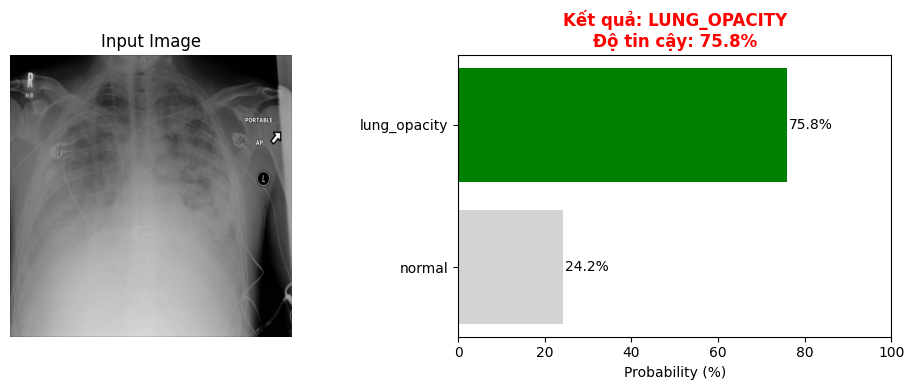

Chẩn đoán : LUNG_OPACITY  (75.8%)
  normal         : 24.2%
  lung_opacity   : 75.8%


('lung_opacity', array([0.24173474, 0.75826526], dtype=float32))

In [119]:
import torch
import torch.nn.functional as F
import pydicom
import numpy as np
from PIL import Image
from torchvision import transforms
from torch.amp import autocast

# ── Load model ──
model_path = '/kaggle/input/datasets/kiwichannnnnnn/fileoutput/best_resnet50.pth'  # ← sửa tên dataset

_model = ResNet50Classifier(num_classes=cfg.NUM_CLASSES, pretrained=False)
_model.load_state_dict(torch.load(model_path, map_location=cfg.DEVICE))
_model.to(cfg.DEVICE).eval()
print(f'✅ Loaded model from {model_path}')

# ── Hàm chẩn đoán 1 ảnh ──
def predict(image_path: str, show: bool = True):
    # Đọc ảnh (hỗ trợ .dcm và ảnh thường)
    if image_path.lower().endswith('.dcm'):
        img_pil = load_dicom_as_pil(image_path)
    else:
        img_pil = Image.open(image_path).convert('RGB')

    # TTA inference
    probs_list = []
    for tfm in tta_transforms:
        img_t = tfm(img_pil).unsqueeze(0).to(cfg.DEVICE)
        with torch.no_grad(), autocast('cuda', enabled=cfg.USE_AMP):
            p = F.softmax(_model(img_t), dim=1)[0].cpu().numpy()
        probs_list.append(p)

    avg_probs  = np.mean(probs_list, axis=0)
    pred_idx   = int(avg_probs.argmax())
    pred_cls   = cfg.CLASSES[pred_idx]
    confidence = avg_probs[pred_idx]

    if show:
        import matplotlib.pyplot as plt
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

        ax1.imshow(img_pil, cmap='gray')
        ax1.axis('off')
        ax1.set_title('Input Image', fontsize=12)

        colors = ['green' if c == pred_cls else 'lightgray' for c in cfg.CLASSES]
        bars = ax2.barh(cfg.CLASSES, avg_probs * 100, color=colors)
        ax2.set_xlim(0, 100)
        ax2.set_xlabel('Probability (%)')
        ax2.set_title(
            f'Kết quả: {pred_cls.upper()}\nĐộ tin cậy: {confidence*100:.1f}%',
            fontsize=12, fontweight='bold',
            color='red' if pred_cls == 'lung_opacity' else 'green'
        )
        for bar, val in zip(bars, avg_probs * 100):
            ax2.text(val + 0.5, bar.get_y() + bar.get_height()/2,
                     f'{val:.1f}%', va='center')
        plt.tight_layout()
        plt.show()

    print(f'Chẩn đoán : {pred_cls.upper()}  ({confidence*100:.1f}%)')
    for i, c in enumerate(cfg.CLASSES):
        print(f'  {c:15s}: {avg_probs[i]*100:.1f}%')

    return pred_cls, avg_probs

# ── Chạy thử ──
predict('/kaggle/input/datasets/tomoeee/dataset/dataset_rsna_final_2class/dataset_rsna_final_2class/test/lung_opacity/0022073f-cec8-42ec-ab5f-bc2314649235.dcm')

